# Import

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt



## Load dataset

In [14]:
macro_dataset = pd.read_csv('data/detailed_meals_macros_.csv')

display(macro_dataset.head(5))
display(macro_dataset.info())

display(macro_dataset.describe().T)

,Ages,Gender,Height,Weight,Activity Level,Dietary Preference,Daily Calorie Target,Protein,Sugar,Sodium,...,Dinner Calories,Dinner Protein.1,Dinner Carbohydrates.1,Dinner Fats,Snack Suggestion,Snacks Calories,Snacks Protein,Snacks Carbohydrates,Snacks Fats,Disease
0,25,Male,180,80,Moderately Active,Omnivore,2000,120,125.0,24.0,...,2020.0,60.0,250.0,60.0,Greek yogurt with fruit,150,10,20,5,Weight Gain
1,32,Female,165,65,Lightly Active,Vegetarian,1600,80,100.0,16.0,...,10.0,5.0,31.0,27.0,Apple with almond butter,180,4,30,8,"Weight Gain, Hypertension, Heart Disease"
2,48,Male,175,95,Sedentary,Vegan,2200,100,150.0,20.0,...,326.0,55.0,150.0,15.0,Trail mix,300,8,34,20,Weight Gain
3,55,Female,160,70,Very Active,Omnivore,2500,140,175.0,28.0,...,278.0,20.0,163.0,27.0,Banana with peanut butter,210,5,30,9,Weight Gain
4,62,Male,170,85,Sedentary,Vegetarian,2000,80,125.0,16.0,...,186.0,6.3,186.0,22.0,Fruit and nut mix,250,6,28,15,Weight Gain


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698 entries, 0 to 1697
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ages                     1698 non-null   int64  
 1   Gender                   1698 non-null   object 
 2   Height                   1698 non-null   int64  
 3   Weight                   1698 non-null   int64  
 4   Activity Level           1698 non-null   object 
 5   Dietary Preference       1698 non-null   object 
 6   Daily Calorie Target     1698 non-null   int64  
 7   Protein                  1698 non-null   int64  
 8   Sugar                    1698 non-null   float64
 9   Sodium                   1698 non-null   float64
 10  Calories                 1698 non-null   int64  
 11  Carbohydrates            1698 non-null   int64  
 12  Fiber                    1698 non-null   float64
 13  Fat                      1698 non-null   int64  
 14  Breakfast Suggestion    

None

,count,mean,std,min,25%,50%,75%,max
Ages,1698.0,43.961720,15.915002,18.0,30.0000,42.00,57.000,79.00
Height,1698.0,174.130153,13.420936,150.0,163.2500,174.00,185.000,200.00
Weight,1698.0,78.064193,16.949264,48.0,64.0000,78.00,91.000,119.00
Daily Calorie Target,1698.0,2275.171967,558.812405,1200.0,1800.0000,2200.00,2689.000,4364.00
Protein,1698.0,139.898115,53.326588,50.0,100.0000,136.00,174.000,327.00
Sugar,1698.0,126.192580,34.938902,60.0,100.0000,124.00,150.000,218.00
Sodium,1698.0,27.979623,10.665318,10.0,20.0000,27.20,34.800,65.40
Calories,1698.0,2196.440518,571.089569,990.0,1770.2500,2146.00,2549.750,4357.00
Carbohydrates,1698.0,252.385159,69.877804,120.0,200.0000,248.00,300.000,436.00
Fiber,1698.0,30.286219,8.385337,14.4,24.0000,29.76,36.000,52.32


# Setup
- This setups the BMI calculations and the features as well as standardizes the numeric features

In [15]:
# Calculate BMI
macro_dataset['Height_m'] = macro_dataset['Height'] / 100  # convert cm → m
macro_dataset['BMI'] = macro_dataset['Weight'] / (macro_dataset['Height_m'] ** 2)

# Create target variable for Obesity (1 if BMI >= 30)
macro_dataset['Obesity'] = np.where(macro_dataset['BMI'] >= 30, 1, 0)

#Select relevant features
features = [
    'Daily Calorie Target', 'Calories', 'Protein', 'Sugar', 'Sodium',
    'Carbohydrates', 'Fiber', 'Fat', 'Activity Level', 'Dietary Preference'
]

x = macro_dataset[features].copy()
y = macro_dataset['Obesity']

le = LabelEncoder()
for col in ["Activity Level", "Dietary Preference"]:
    x[col] = le.fit_transform(x[col])


# Standardize numeric features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

#Summary

print("Setup Complete")
print("Features matrix shape:", X_scaled.shape)
print("Target distribution (0=not obese), 1=Obese):\n", y.value_counts())
X_scaled.head()


Setup Complete
Features matrix shape: (1698, 10)
Target distribution (0=not obese), 1=Obese):
 Obesity
0    1329
1     369
Name: count, dtype: int64


,Daily Calorie Target,Calories,Protein,Sugar,Sodium,Carbohydrates,Fiber,Fat,Activity Level,Dietary Preference
0,-0.492568,-0.309045,-0.373247,-0.034143,-0.373247,-0.034143,-0.034143,-0.452793,-0.196012,-1.263487
1,-1.208582,-1.254885,-1.123563,-0.749889,-1.123563,-0.749889,-0.749889,-1.386309,-1.001893,1.235039
2,-0.134561,-0.020039,-0.748405,0.681602,-0.748405,0.681602,0.681602,-0.219415,0.609868,0.402197
3,0.402450,0.846981,0.001911,1.397348,0.001911,1.397348,1.397348,0.480722,1.415749,-1.263487
4,-0.492568,-0.668114,-1.123563,-0.034143,-1.123563,-0.034143,-0.034143,-0.686172,0.609868,1.235039


## Basic Cleaning of  data
- Removing trailing spaces
- Drop rows with missing target variables
- Fill or drop missing values


In [16]:

# Remove trailing spaces
macro_dataset = macro_dataset.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Normalize text casing for categorical columns
text_cols = ['Gender', 'Activity Level', 'Dietary Preference', 'Disease']
for col in text_cols:
    if col in macro_dataset.columns:
        macro_dataset[col] = macro_dataset[col].str.title()


#Remove duplicate rows
macro_dataset.drop_duplicates(inplace=True)

#Summary & Check
print("Data cleaned successfully!\n")
print("Remaining missing values per column:\n", macro_dataset.isnull().sum())
print("\nData shape after cleaning:", macro_dataset.shape)
print("\nUnique Dietary Preferences:", macro_dataset['Dietary Preference'].unique())
print("Unique Diseases:", macro_dataset['Disease'].unique())

Data cleaned successfully!

Remaining missing values per column:
 Ages                       0
Gender                     0
Height                     0
Weight                     0
Activity Level             0
Dietary Preference         0
Daily Calorie Target       0
Protein                    0
Sugar                      0
Sodium                     0
Calories                   0
Carbohydrates              0
Fiber                      0
Fat                        0
Breakfast Suggestion       0
Breakfast Calories         0
Breakfast Protein          0
Breakfast Carbohydrates    1
Breakfast Fats             0
Lunch Suggestion           0
Lunch Calories             0
Lunch Protein              0
Lunch Carbohydrates        0
Lunch Fats                 0
Dinner Suggestion          0
Dinner Calories            0
Dinner Protein.1           0
Dinner Carbohydrates.1     0
Dinner Fats                0
Snack Suggestion           0
Snacks Calories            0
Snacks Protein             0
Snacks

# High Correlation Filter

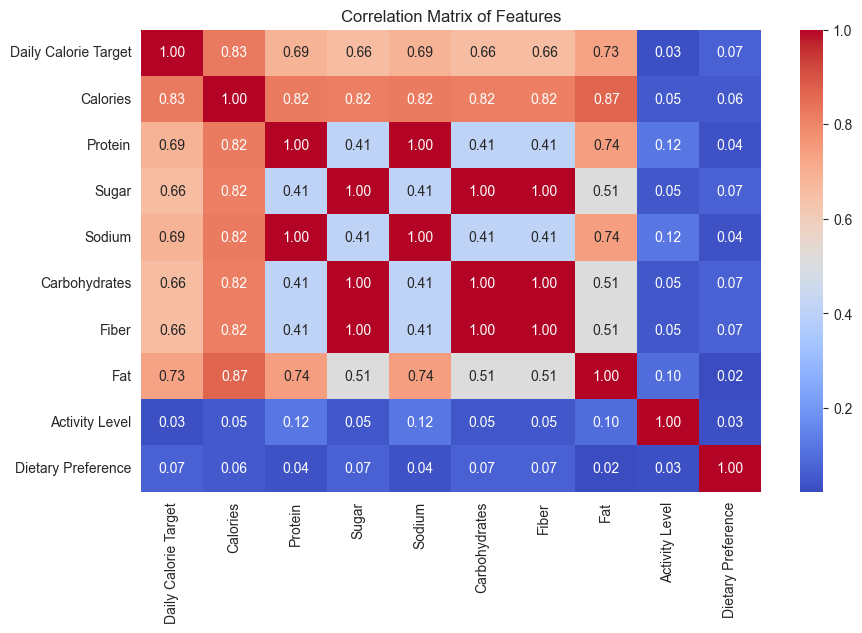

 Highly correlated features (correlation > 0.8):
['Calories', 'Protein', 'Sugar', 'Sodium', 'Carbohydrates', 'Fiber', 'Fat']

Remaining features after filtering:
['Daily Calorie Target', 'Activity Level', 'Dietary Preference']


In [17]:

#Compute correlation matrix
corr_matrix = X_scaled.corr().abs()

#Visualize correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

#Identify highly correlated features (correlation > 0.8)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]

print(" Highly correlated features (correlation > 0.8):")
print(high_corr_features if high_corr_features else "No highly correlated features found.")

# Drop correlated features for next steps
X_corr_filtered = X_scaled.drop(columns=high_corr_features, errors='ignore')
print("\nRemaining features after filtering:")
print(X_corr_filtered.columns.tolist())


# Backword/Forward Feature Selection

In [18]:
# Uses logistic regression as estimator

model = LogisticRegression(max_iter=500)

#Apply rfe to select top 5 features
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_corr_filtered, y)

selected_features = X_corr_filtered.columns[rfe.support_].tolist()

print("Top features Selected")
print(selected_features)

#Create reduce dataset for modelling

X_selected= X_corr_filtered[selected_features]
X_selected.head()

Top features Selected
['Daily Calorie Target', 'Activity Level', 'Dietary Preference']


C:\Users\jjbed\Downloads\GroupPresentation4\.venv\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=5 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


,Daily Calorie Target,Activity Level,Dietary Preference
0,-0.492568,-0.196012,-1.263487
1,-1.208582,-1.001893,1.235039
2,-0.134561,0.609868,0.402197
3,0.402450,1.415749,-1.263487
4,-0.492568,0.609868,1.235039


## Principal Component Analysis